## Inventory Discrepancy Analysis

The data comes from inventory_transactions_data.xlsx, a single tab of inventory changes. When someone makes a manual adjustment, they note it in the comment field, though there is no consistent wording. That comment field is our trail for tracking discrepancies.
- Total rows: 537,499
- Dollar change is taken from the cost column, with blanks counted as zero

The goal is to dig into that discrepancy trail:
- When did inventory adjustments spike, and are they growing or fading?
- Which specific months stand out in count or dollars?
- Does the dollar change lean consistently one way?
- Do groups of items fall into distinct patterns?
- What should we keep an eye on going forward?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import SymLogNorm
from matplotlib.ticker import FuncFormatter
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from IPython.display import display

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
#plt.rcParams.update({'figure.facecolor': '#2b2b2b', 'axes.facecolor': '#3a3a3a', 'axes.edgecolor': '#888', 'axes.labelcolor': 'white', 'xtick.color': 'white', 'ytick.color': 'white', 'text.color': 'white', 'grid.color': '#555', 'axes.titlecolor': 'white'})

def dollars(v, _=None):
    a = abs(v)
    s = f'${a/1e6:,.2f}M' if a >= 1e6 else f'${a/1e3:,.0f}K' if a >= 1e3 else f'${a:,.0f}'
    return ('-' + s) if v < 0 else s

## Data Overview

A quick read on all 537,499 rows, calculated directly from the data so it stays reproducible.
- Transactions per year: the trend in how many changes happen, noting that 2026 is a partial year.
- Dollars per year: the same trend in dollar terms.
- Transactions by type: sales dominate, with a large share going to physical counts and quantity adjustments that keep inventory accurate.
- Data completeness: how much of each field is filled in, noting the comment field is mostly empty.

Rows = 537,499
Items = 6,369
Loc 01 Share = 98%

Date Range = 2005-01-03 to 2026-07-13


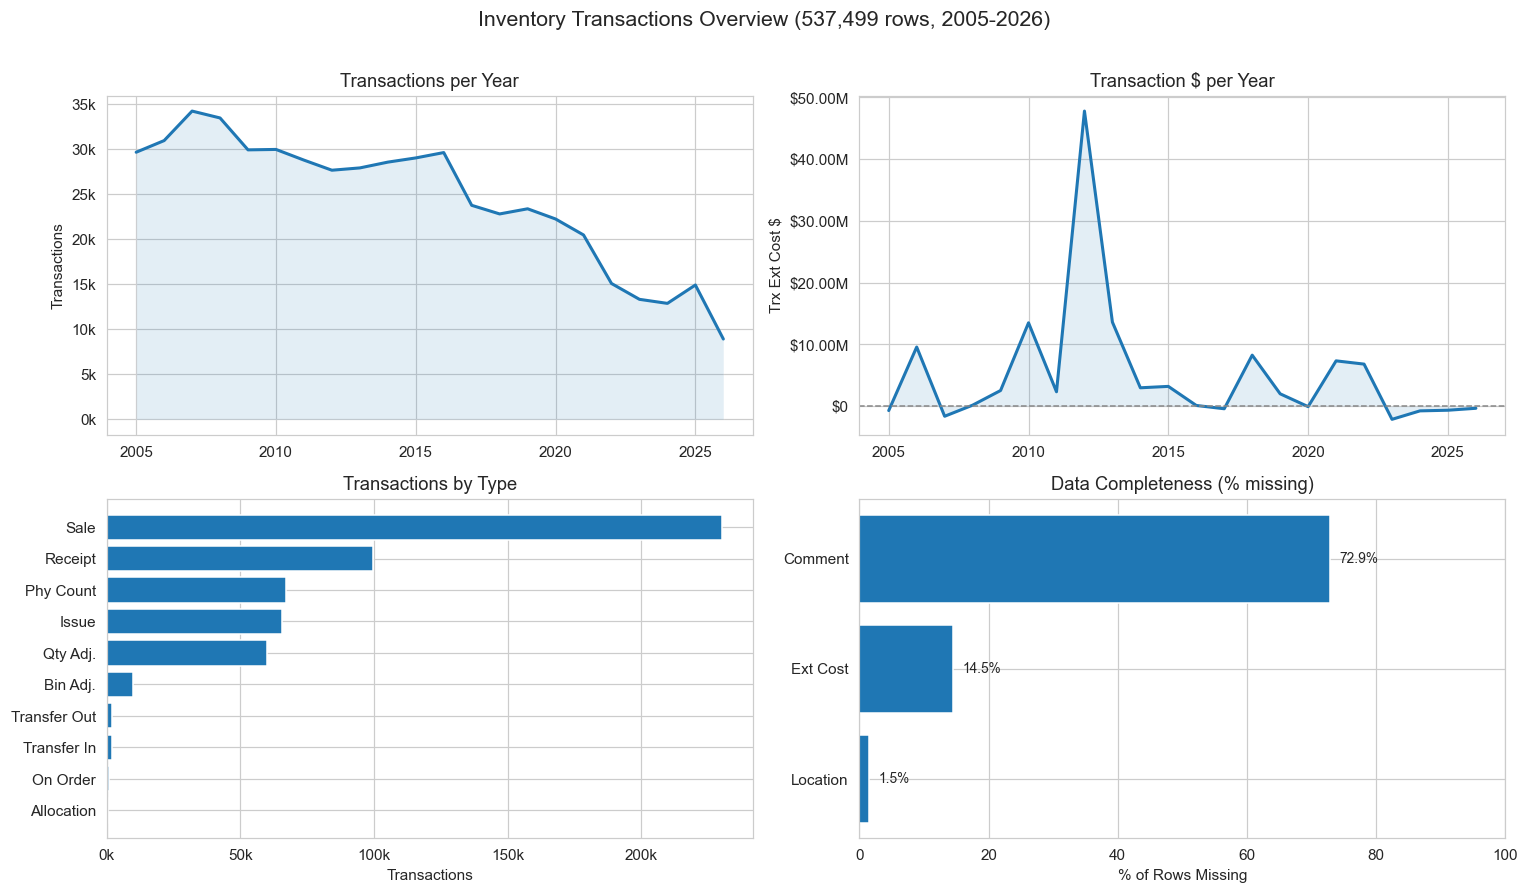

In [2]:
datafile = 'inventory_transactions_data.xlsx'
df = pd.read_excel(datafile)
df['date'] = pd.to_datetime(df['Trx Dt'])
df['year'] = df['date'].dt.year
print(f"Rows = {len(df):,}")
print(f"Items = {df['Item #'].nunique():,}")
print(f"Loc 01 Share = {(df['Loc'].astype(str).str.strip() == '01').mean():.0%}")
print()
print(f"Date Range = {df['date'].min().date()} to {df['date'].max().date()}")

fig, ax = plt.subplots(2, 2, figsize=(14, 8))
py = df.groupby('year').size()
ax[0, 0].fill_between(py.index, py.values, alpha=0.12)
ax[0, 0].plot(py.index, py.values, lw=2)
ax[0, 0].set(title='Transactions per Year', ylabel='Transactions')
ax[0, 0].yaxis.set_major_formatter(lambda v, _: f'{v/1000:.0f}k')
pv = df.groupby('year')['Trx Ext Cost $'].sum()
ax[0, 1].fill_between(pv.index, pv.values, alpha=0.12)
ax[0, 1].plot(pv.index, pv.values, lw=2)
ax[0, 1].axhline(0, color='#888', ls='--', lw=1)
ax[0, 1].set(title='Transaction $ per Year', ylabel='Trx Ext Cost $')
ax[0, 1].yaxis.set_major_formatter(FuncFormatter(dollars))
tt = df['Trx Type'].value_counts().sort_values()
ax[1, 0].barh(tt.index, tt.values)
ax[1, 0].set(title='Transactions by Type', xlabel='Transactions')
ax[1, 0].xaxis.set_major_formatter(lambda v, _: f'{v/1000:.0f}k')
name_map = {'Trx Comment': 'Comment', 'Trx Ext Cost $': 'Ext Cost', 'Loc': 'Location'}
miss = (df[list(name_map)].isna().sum() / len(df) * 100).rename(name_map).sort_values()
ax[1, 1].barh(miss.index, miss.values)
ax[1, 1].set(title='Data Completeness (% missing)', xlabel='% of Rows Missing', xlim=(0, 100))

for y_, v in enumerate(miss.values):
    ax[1, 1].text(v + 1.5, y_, f'{v:.1f}%', va='center', fontsize=9)
fig.suptitle(f"Inventory Transactions Overview ({len(df):,} rows, {df['year'].min()}-{df['year'].max()})", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

## Narrowing to Real Discrepancies

We keep a row only when all three of these are true:
- It has a comment, not a blank.
- The item number starts with a digit, which drops non-parts like ORDER, FAB, and OUTSIDE MFG.
- The comment does not mention "cut," which drops routine fabrication notes.

In [3]:
has_comment = df['Trx Comment'].notna() & (df['Trx Comment'].astype(str).str.strip() != '')
item_str = df['Item #'].fillna('').astype(str).str.strip()
starts_digit = item_str.str[:1].str.isdigit()
no_cut = ~df['Trx Comment'].astype(str).str.contains('cut', case=False, na=False)
cdf = df[has_comment & starts_digit & no_cut].copy()
cdf['Year'] = cdf['Trx Dt'].dt.year
cdf['Month'] = cdf['Trx Dt'].dt.month

print(f"Total Rows = {len(df):,}")
print(f"Rows with a Trx Comment from Above Total = {int(has_comment.sum()):,}")
print(f"Item # Starts with a Digit from Above Total = {int((has_comment & starts_digit).sum()):,}")
print(f"Comment Does Not Contain 'cut' from Above Total = {len(cdf):,} ({len(cdf) / len(df):.1%} of all rows)")
cdf.head()

Total Rows = 537,499
Rows with a Trx Comment from Above Total = 145,895
Item # Starts with a Digit from Above Total = 134,037
Comment Does Not Contain 'cut' from Above Total = 82,515 (15.4% of all rows)


,Trx Dt,Loc,Item #,Trx Type,Trx Old Qty,Trx New O/H Qty,Trx Qty,Trx Ext Cost $,Trx Comment,date,year,Year,Month
0,2005-01-03,01,041022048096100,Receipt,127,126.00,-1.00,-62.52,ADJUSTING ENTRY FOR QOH CHANGE,2005-01-03,2005,2005,1
9,2005-01-04,01,041012548096100,Issue,207,203.00,4.00,-122.50,FAB-ANDY,2005-01-04,2005,2005,1
12,2005-01-04,NaN,041050048096100,Issue,20,14.00,6.00,-867.84,FAB-ANDY,2005-01-04,2005,2005,1
19,2005-01-04,01,061012560961100,Issue,12,2.00,10.00,-710.00,FAB-ANDY,2005-01-04,2005,2005,1
20,2005-01-04,01,061022048961811,Issue,6,3.00,3.00,-308.16,FAB-ANDY,2005-01-04,2005,2005,1


That leaves 82,515 rows, about 15% of the original data.

## Broken Down by Year

The flagged rows split out by year: first a summary of how many rows and the net dollar change, then the full detail for each year.

In [4]:
yearly = cdf.groupby('Year').agg(rows=('Trx Comment', 'size'), total_amt=('Trx Ext Cost $', 'sum')).reset_index()
print(f"Years Covered = {len(yearly):,}")

display(yearly.style.hide(axis='index').format({'Year': '{:.0f}', 'rows': '{:,}', 'total_amt': '${:,.2f}'}).background_gradient(subset=['rows'], cmap='Reds'))

Years Covered = 22


Year,rows,total_amt
2005,"4,987","$-1,389,441.07"
2006,"4,846","$-1,985,135.28"
2007,"9,194","$-1,420,811.28"
2008,"7,444","$-217,788.87"
2009,"5,580","$-153,025.78"
2010,"5,293","$-74,163.88"
2011,"4,966","$1,967,827.76"
2012,"5,410","$-106,440.54"
2013,"5,203","$-37,053.38"
2014,"5,032","$-94,320.31"


In [5]:
for y in sorted(cdf['Year'].unique()):
    g = cdf[cdf['Year'] == y].drop(columns=['date', 'year', 'Year', 'Month']).reset_index(drop=True)
    print(f"{y} | {len(g):,} rows | net Trx Ext Cost $ = {g['Trx Ext Cost $'].sum():,.2f} ")
    display(g)

2005 | 4,987 rows | net Trx Ext Cost $ = -1,389,441.07 


,Trx Dt,Loc,Item #,Trx Type,Trx Old Qty,Trx New O/H Qty,Trx Qty,Trx Ext Cost $,Trx Comment
0,2005-01-03,01,041022048096100,Receipt,127,126.00,-1.00,-62.52,ADJUSTING ENTRY FOR QOH CHANGE
1,2005-01-04,01,041012548096100,Issue,207,203.00,4.00,-122.50,FAB-ANDY
2,2005-01-04,NaN,041050048096100,Issue,20,14.00,6.00,-867.84,FAB-ANDY
3,2005-01-04,01,061012560961100,Issue,12,2.00,10.00,-710.00,FAB-ANDY
4,2005-01-04,01,061022048961811,Issue,6,3.00,3.00,-308.16,FAB-ANDY
...,...,...,...,...,...,...,...,...,...
4982,2005-12-30,01,43220001,Bin Adj.,0,0.00,-8.00,NaN,STOCK OUT
4983,2005-12-30,01,421025048096020,Issue,54,53.00,1.00,-52.79,FAB-ANDY
4984,2005-12-30,01,43220001,Qty Adj.,8,0.00,-8.00,-85.12,STOCK OUT
4985,2005-12-30,01,9031001,Issue,178,166.00,12.00,-27.06,FAB-ANDY


2006 | 4,846 rows | net Trx Ext Cost $ = -1,985,135.28 


,Trx Dt,Loc,Item #,Trx Type,Trx Old Qty,Trx New O/H Qty,Trx Qty,Trx Ext Cost $,Trx Comment
0,2006-01-03,01,4020150000,Issue,111,106.00,5.00,-7.81,ANDY/ERIC FAB
1,2006-01-03,01,43220001,Qty Adj.,0,8.00,8.00,85.12,FOUND MATERIAL
2,2006-01-03,01,43220001,Bin Adj.,8,8.00,8.00,NaN,FOUND MATERIAL
3,2006-01-04,NaN,041009348096110,Issue,83,80.00,3.00,-75.84,FAB-ANDY
4,2006-01-04,01,041012548096100,Issue,77,76.00,1.00,-32.71,FAB-ANDY
...,...,...,...,...,...,...,...,...,...
4841,2006-12-28,01,30105004809611,Issue,18,17.00,1.00,-132.08,FAB-ANDY
4842,2006-12-29,01,041009348096100,Issue,80,79.00,1.00,-30.72,FAB-W.P.
4843,2006-12-29,01,041022048096100,Issue,55,17.00,38.00,"-2,316.77",FAB-W.P.
4844,2006-12-29,01,074RB32,Issue,9,8.00,1.00,-6.15,MELCALA CORP.


2007 | 9,194 rows | net Trx Ext Cost $ = -1,420,811.28 


...

,Trx Dt,Loc,Item #,Trx Type,Trx Old Qty,Trx New O/H Qty,Trx Qty,Trx Ext Cost $,Trx Comment
0,2024-01-04,01,382011251V,Receipt,0,37.00,37.00,217.54,PO83069 as B = 37.75ft XP
1,2024-01-04,01,382011251V,Issue,37,3.00,34.00,-199.91,Disregard PO83069 comment XP
2,2024-01-09,01,041012548096MAR,Issue,349,324.00,25.00,-926.71,Weiss Aug
3,2024-01-09,01,5011000DROP,Receipt,0,25.00,25.00,0.00,Inv adj to inv XP
4,2024-01-10,01,261002504809600,Receipt,15,24.00,9.00,537.21,Inv adj to invoice XP
...,...,...,...,...,...,...,...,...,...
480,2024-12-09,01,21205001000,Issue,350,0.00,350.00,-294.99,Cycle count adj XP
481,2024-12-09,01,21205002000,Receipt,139,254.00,115.00,111.71,Cycle count adj XP
482,2024-12-10,01,041125048096000,Issue,2,0.00,2.00,"-1,292.44",Inv adj XP
483,2024-12-11,01,313S39A,Issue,1200,400.00,800.00,"-1,280.22",Initially sold w/ no part# XP


2025 | 392 rows | net Trx Ext Cost $ = -68,048.83 


,Trx Dt,Loc,Item #,Trx Type,Trx Old Qty,Trx New O/H Qty,Trx Qty,Trx Ext Cost $,Trx Comment
0,2025-01-02,01,243475045000000,Issue,88,0.00,88.00,"-9,090.56",Inv adj
1,2025-01-08,01,041012548096MAR,Issue,10,4.00,6.00,-213.09,Cycle count adj XP
2,2025-01-08,01,041022048096000,Issue,1,0.00,1.00,-75.20,Cycle count adj XP
3,2025-01-08,01,041022048096MAR,Issue,11,0.00,11.00,-745.31,Cycle count adj XP
4,2025-01-08,01,041037548096000,Receipt,18,22.00,4.00,624.00,Cycle count adj XP
...,...,...,...,...,...,...,...,...,...
387,2025-12-08,01,02200375200,Issue,610,600.00,10.00,-3.00,Inv adj XP
388,2025-12-09,01,7124480962100,Issue,208,193.00,15.00,-106.02,Cycle count adj XP
389,2025-12-15,01,3422252,Receipt,0,8.00,8.00,299.68,Extra material returned XP
390,2025-12-23,01,382001871V,Issue,126,72.00,54.00,-13.50,Replacement missed rcving


2026 | 670 rows | net Trx Ext Cost $ = -51,175.36 


,Trx Dt,Loc,Item #,Trx Type,Trx Old Qty,Trx New O/H Qty,Trx Qty,Trx Ext Cost $,Trx Comment
0,2026-01-05,01,041075060096000,Issue,1,0.00,1.00,-378.10,Cycle count adj XP
1,2026-01-05,01,261005004812000,Issue,2,0.00,2.00,-255.37,Cycle count adj XP
2,2026-01-06,01,02200375200,Issue,600,580.00,20.00,-7.60,Cycle count adj XP
3,2026-01-06,01,02200187100,Issue,884,464.00,420.00,-125.69,Cycle count adj XP
4,2026-01-06,01,02200500102,Receipt,56,64.00,8.00,25.52,Cycle count adj XP
...,...,...,...,...,...,...,...,...,...
665,2026-07-10,01,4020150000,Issue,565,165.00,400.00,"-1,021.20",Fixing BB PO 87122 Data Entry
666,2026-07-13,01,06101254896TWAY,Transfer Out,5,0.00,5.00,-553.55,Bin Transfer
667,2026-07-13,01,06101254896TWAY,Transfer In,5,10.00,5.00,553.55,Bin Transfer
668,2026-07-13,01,24112548096MIRR,Transfer Out,13,12.00,1.00,-490.41,Bin Transfer


The trail is heavily weighted toward the early years.
- 2005 to 2007 each carry thousands of rows, peaking at 9,194 in 2007.
- Net dollar swings run from about -1.4M to -2.0M in those years.
- It shrinks to a few hundred rows a year by 2023 to 2026, mirroring the overall drop in transactions.
- The net is negative in 20 of the 22 years, so these comments mostly track downward adjustments.
- The two exceptions, 2011 at +2.0M and 2015 at +1.2M, get a closer look below.

## Yearly Trend

Row count and net dollar change per year, shown together so the volume trend and the dollar trend can be read side by side.

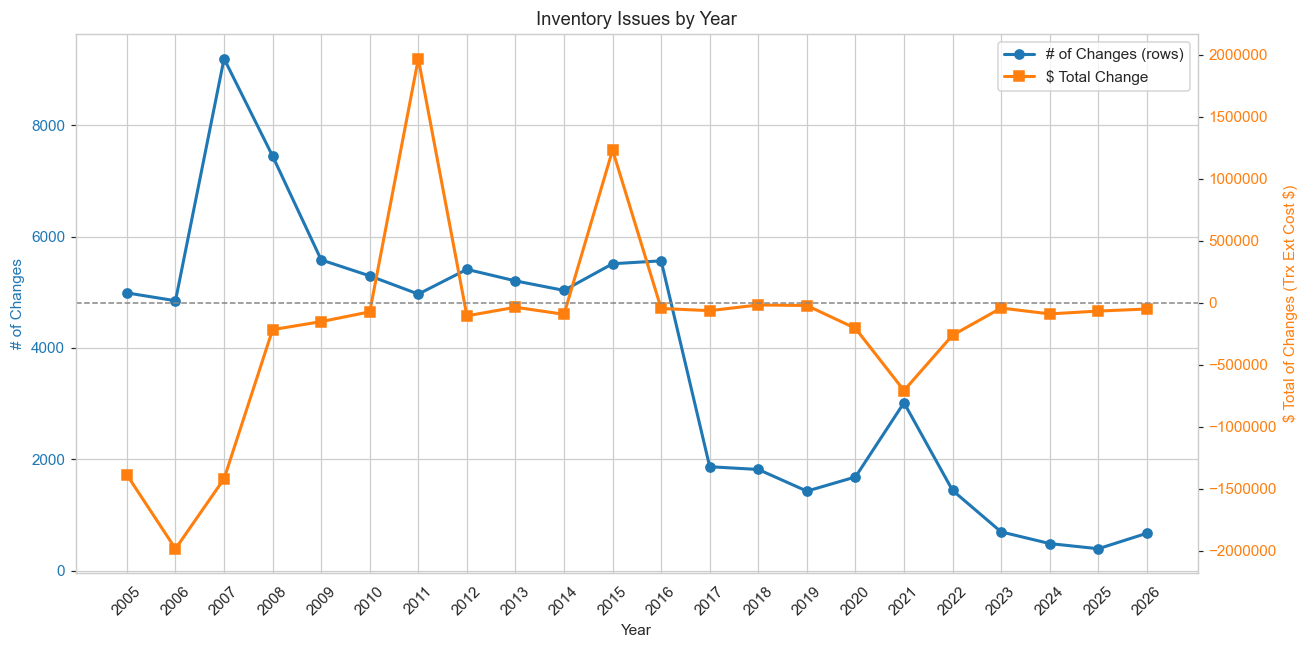

In [6]:
fig, ax1 = plt.subplots(figsize=(12, 6))
l1, = ax1.plot(yearly['Year'], yearly['rows'], color='tab:blue', marker='o', lw=2, label='# of Changes (rows)')
ax1.set_xlabel('Year')
ax1.set_ylabel('# of Changes', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticks(yearly['Year'])
ax1.set_xticklabels(yearly['Year'], rotation=45)
ax2 = ax1.twinx()
l2, = ax2.plot(yearly['Year'], yearly['total_amt'], color='tab:orange', marker='s', lw=2, label='$ Total Change')
ax2.set_ylabel('\\$ Total of Changes (Trx Ext Cost \\$)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')
ax2.ticklabel_format(style='plain', axis='y')
ax2.axhline(0, color='#888', ls='--', lw=1)
ax2.grid(False)
ax1.legend(handles=[l1, l2], loc='upper right')
ax1.set_title('Inventory Issues by Year')

plt.tight_layout(); plt.show()


## A Closer Look at 2011 and 2015

Both years show up as big positive spikes above. Here we check their largest positive transactions:
- Net change: the year's net dollar change as charted.
- Largest single row: the biggest single dollar entry that year.
- Net without that row: the same year with just that one entry removed.

In [7]:
top_idx = cdf.groupby('Year')['Trx Ext Cost $'].idxmax()
biggest = cdf.loc[top_idx].set_index('Year')
trimmed = cdf.drop(index=top_idx).groupby('Year')['Trx Ext Cost $'].sum()
check_years = yearly[yearly['total_amt'] > 0]['Year'].tolist()
checks = pd.DataFrame({'net_amt': yearly.set_index('Year')['total_amt'], 'top_row_amt': biggest['Trx Ext Cost $'], 'net_less_top_row': trimmed, 'top_row_item': biggest['Item #'].str.strip(), 'top_row_comment': biggest['Trx Comment'].str.strip()}).loc[check_years]

print(f"Years to be Checked = {check_years}")
print(f"Positive $ Rows (whole trail) = {int((cdf['Trx Ext Cost $'] > 0).sum()):,} of {len(cdf):,} ({(cdf['Trx Ext Cost $'] > 0).mean():.0%})")

display(checks.style.format({'net_amt': '${:,.2f}', 'top_row_amt': '${:,.2f}', 'net_less_top_row': '${:,.2f}'}).background_gradient(subset=['top_row_amt'], cmap='Greens'))

Years to be Checked = [2011, 2015]
Positive $ Rows (whole trail) = 12,959 of 82,515 (16%)


,net_amt,top_row_amt,net_less_top_row,top_row_item,top_row_comment
Year,,,,,
2011,"$1,967,827.76","$2,070,192.00","$-102,364.24",0440087510,fix pricing
2015,"$1,231,009.50","$1,312,357.50","$-81,348.00",911ABS10,Final Qty Adjustment For Count


Both years flip to negative the moment their single largest entry is removed.
- 2011 rests on a single +2,070,192 adjustment labeled "fix pricing." Without it, the year is -102,364.
- 2015 rests on a single +1,312,358 adjustment labeled "Final Qty Adjustment For Count." Without it, the year is -81,348.
- Removing just those two entries, the whole trail nets -7.2M instead of -3.9M.

Takeaway:
- A single entry can carry an entire year, so always check the largest adjustments before trusting any dollar total.
- More likely, this points to a process problem from the lack of a consistent standard, or possibly deliberate manipulation of the numbers.

## Monthly Trend, Last 5 Years

This zooms into the five most recent years in the data, chosen automatically so it keeps rolling forward as new data arrives.
- Each year is a line across the calendar months.
- One chart shows row count, the other shows net dollars.
- The most recent year is only partway through, so its line stops at the last month on file.

In [8]:
recent_years = sorted(cdf['Year'].unique())[-5:]
print(f"Years Plotted = {recent_years[0]} to {recent_years[-1]}")

sub = cdf[cdf['Year'].isin(recent_years)]
monthly_rows = sub.groupby(['Year', 'Month']).size().unstack('Year').reindex(range(1, 13))
monthly_amt = sub.groupby(['Year', 'Month'])['Trx Ext Cost $'].sum().unstack('Year').reindex(range(1, 13))
monthly_rows

Years Plotted = 2022 to 2026


Year,2022,2023,2024,2025,2026
Month,,,,,
1,176.00,43.00,25.00,31.00,380.00
2,215.00,43.00,42.00,49.00,46.00
3,200.00,62.00,48.00,23.00,30.00
4,196.00,55.00,37.00,47.00,49.00
5,118.00,30.00,49.00,36.00,23.00
6,102.00,39.00,21.00,69.00,115.00
7,124.00,24.00,24.00,46.00,27.00
8,63.00,50.00,31.00,25.00,NaN
9,76.00,35.00,38.00,30.00,NaN


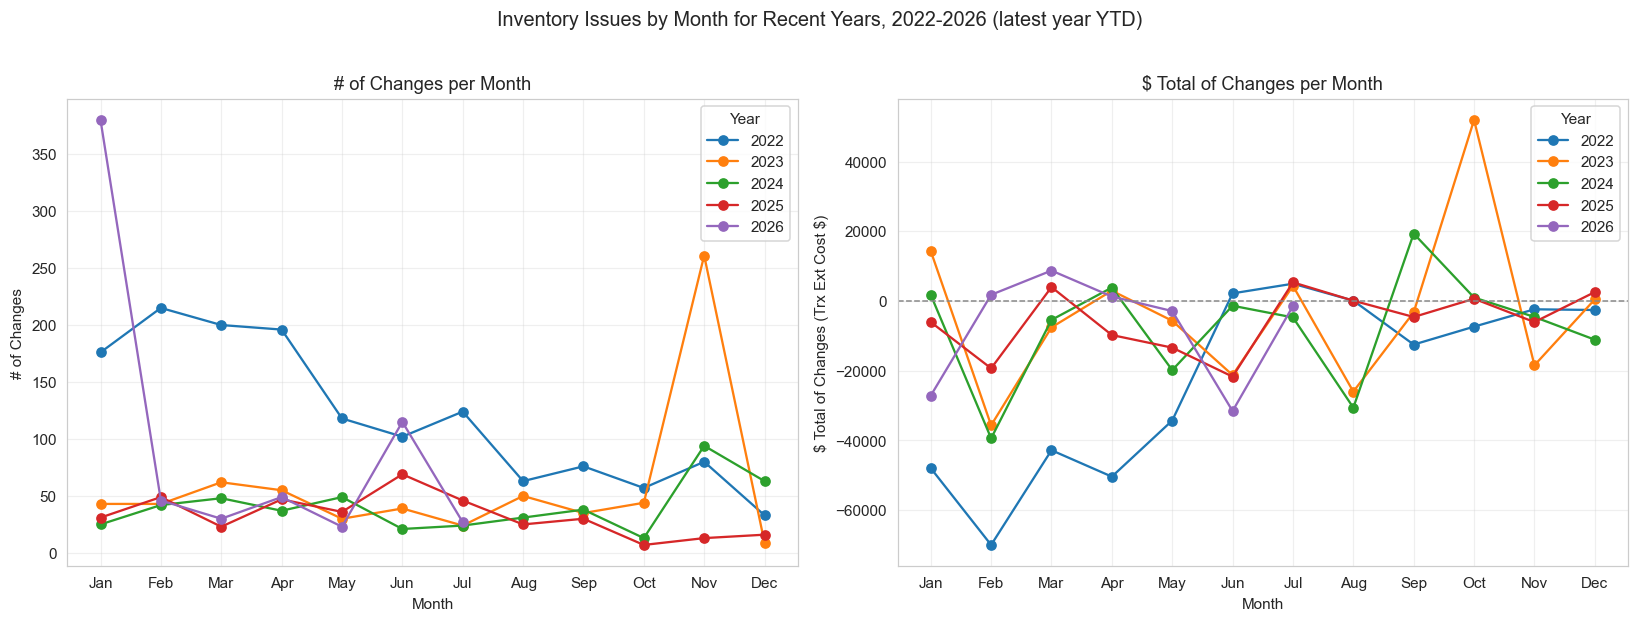

In [9]:
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 5.5))
for y in recent_years:
    if y in monthly_rows.columns:
        axL.plot(monthly_rows.index, monthly_rows[y], marker='o', label=str(y))
    if y in monthly_amt.columns:
        axR.plot(monthly_amt.index, monthly_amt[y], marker='o', label=str(y))
for ax, title, ylab in [(axL, '# of Changes per Month', '# of Changes'), (axR, '\\$ Total of Changes per Month', '\\$ Total of Changes (Trx Ext Cost $)')]:
    ax.set(title=title, xlabel='Month', ylabel=ylab)
    ax.set_xticks(range(1, 13)); ax.set_xticklabels(month_labels)
    ax.legend(title='Year'); ax.grid(alpha=0.3)
axR.axhline(0, color='#888', ls='--', lw=1)
fig.suptitle(f'Inventory Issues by Month for Recent Years, {recent_years[0]}-{recent_years[-1]} (latest year YTD)', y=1.02, fontsize=13)

plt.tight_layout(); plt.show()

## Flagging Unusual Months

For each measure we look at how much it changed from one month to the next, then flag any month whose change is far outside the normal range.
- Change: this month minus last month.
- A positive change is an upswing, a negative one a downswing.
- How far is "far" is set by a threshold at the top of the code. Lower it to catch more months, raise it to keep only the most extreme.

Everything recalculates automatically as new data is added.

In [10]:
z_thresh = 2.0

recent = cdf[cdf['Year'].isin(recent_years)]
monthly = recent.groupby(pd.Grouper(key='Trx Dt', freq='MS')).agg(rows=('Trx Comment', 'size'), amount=('Trx Ext Cost $', 'sum'))
monthly = monthly.reindex(pd.date_range(monthly.index.min(), monthly.index.max(), freq='MS'), fill_value=0)

records = []
for col, label in [('rows', '# of Changes'), ('amount', '$ Total of Changes')]:
    delta = monthly[col].diff()
    z = (delta - delta.mean()) / delta.std()
    prev = monthly[col].shift(1)
    for dt in monthly.index:
        if pd.notna(z.loc[dt]) and abs(z.loc[dt]) >= z_thresh:
            p, c = prev.loc[dt], monthly[col].loc[dt]
            records.append({'month': dt.strftime('%Y-%m'), 'metric': label, 'swing': 'Upswing' if c >= p else 'Downswing', 'previous': p, 'current': c, 'change': c - p, 'pct': (c - p) / abs(p) if p != 0 else np.nan, 'z': z.loc[dt]})

anomalies = pd.DataFrame(records).assign(abs_z=lambda d: d['z'].abs()).sort_values('abs_z', ascending=False).reset_index(drop=True)
print(f"Flagged Months = {len(anomalies):,} at z_thresh = {z_thresh}")

display(anomalies.drop(columns='abs_z').style.hide(axis='index').format({'previous': '{:,.2f}', 'current': '{:,.2f}', 'change': '{:,.2f}', 'pct': '{:.1%}', 'z': '{:.2f}'}).background_gradient(subset=['z'], cmap='RdBu'))

Flagged Months = 8 at z_thresh = 2.0


month,metric,swing,previous,current,change,pct,z
2026-01,# of Changes,Upswing,16.00,380.00,364.00,2275.0%,4.20
2026-02,# of Changes,Downswing,380.00,46.00,-334.00,-87.9%,-3.79
2023-11,$ Total of Changes,Downswing,"51,966.88","-18,429.29","-70,396.18",-135.5%,-2.97
2023-12,# of Changes,Downswing,261.00,9.00,-252.00,-96.6%,-2.85
2023-11,# of Changes,Upswing,44.00,261.00,217.00,493.2%,2.51
2023-10,$ Total of Changes,Upswing,"-3,232.37","51,966.88","55,199.26",1707.7%,2.27
2023-02,$ Total of Changes,Downswing,"14,345.15","-35,647.34","-49,992.49",-348.5%,-2.12
2024-09,$ Total of Changes,Upswing,"-30,588.25","19,357.27","49,945.52",163.3%,2.05


## What Drove Each Flagged Month

The actual inventory rows behind each flagged month, largest negative entries first, so you can see what caused the swing.

In [11]:
for ym in sorted(anomalies['month'].unique()):
    period = pd.Period(ym, freq='M')
    detail = recent[recent['Trx Dt'].dt.to_period('M') == period].sort_values('Trx Ext Cost $', ascending=True).drop(columns=['date', 'year', 'Year', 'Month']).reset_index(drop=True)
    tags = ', '.join(f'{r.metric} {r.swing}' for r in anomalies[anomalies['month'] == ym].itertuples())
    print(f" {ym} | {len(detail):,} inventory issue rows ({tags})")
    display(detail)

 2023-02 | 43 inventory issue rows ($ Total of Changes Downswing)


,Trx Dt,Loc,Item #,Trx Type,Trx Old Qty,Trx New O/H Qty,Trx Qty,Trx Ext Cost $,Trx Comment
0,2023-02-22,01,2280325011,Issue,1200,590.00,610.00,"-15,908.80",adjusted 2/22/23 - sa
1,2023-02-14,01,021003754809600,Issue,23,13.00,10.00,"-4,600.00",adjusted 2/14/23 - sa
2,2023-02-14,01,021005004809610,Issue,6,0.00,6.00,"-3,903.36",adjusted 2/14/23 - sa
3,2023-02-14,01,021007504809600,Issue,8,4.00,4.00,"-3,628.00",adjusted 2/14/23 - sa
4,2023-02-14,01,021002504809600,Issue,10,2.00,8.00,"-2,608.00",adjusted 2/14/23 - sa
5,2023-02-14,01,151009336048100,Issue,31,4.00,27.00,"-1,740.69",adjusted 2/14/23 - sa
6,2023-02-16,01,011012548096111,Issue,121,91.00,30.00,"-1,694.10",adjusted 2/16
7,2023-02-10,01,241187601200000,Issue,9,0.00,9.00,-945.00,Cycle Count Adj XP
8,2023-02-03,01,421050048096020,Issue,12,7.00,5.00,-892.11,Cycle Count Adj XP
9,2023-02-17,01,041022048096MAR,Issue,314,302.00,12.00,-849.37,adjusted 2/17/23 - sa


 2023-10 | 44 inventory issue rows ($ Total of Changes Upswing)


,Trx Dt,Loc,Item #,Trx Type,Trx Old Qty,Trx New O/H Qty,Trx Qty,Trx Ext Cost $,Trx Comment
0,2023-10-18,01,421006048096020,Issue,342,44.00,298.00,"-6,079.20",Simona direct coded wrong
1,2023-10-03,01,2220125010,Issue,1540,770.00,770.00,"-4,052.77",adjusted sa - 10/3
2,2023-10-03,01,2220125010,Issue,2310,"1,540.00",770.00,"-4,052.77",adjusted 10/3- sa
3,2023-10-17,01,3060300022,Issue,300,0.00,300.00,"-1,681.27","Inv Adj: Dry Rot, Cat Piss"
4,2023-10-23,01,4411248096BLAS,Issue,28,10.00,18.00,"-1,476.36",Inv adj old part# 10 allocated
5,2023-10-03,01,2220100010,Issue,274,14.00,260.00,-856.35,adjusted sa - 10/3
6,2023-10-19,01,05021112504896M,Issue,18,8.00,10.00,-690.90,Cycle Count Adj XP
7,2023-10-03,01,261002504809600,Issue,20,12.00,8.00,-502.64,adjusted sa - 10/3
8,2023-10-10,01,02201000BMT,Issue,53,3.00,50.00,-456.56,ADJUESTED 10/10-SA
9,2023-10-25,01,261007504809620,Issue,8,6.00,2.00,-440.52,Cycle Count Adj XP


 2023-11 | 261 inventory issue rows ($ Total of Changes Downswing, # of Changes Upswing)


...

,Trx Dt,Loc,Item #,Trx Type,Trx Old Qty,Trx New O/H Qty,Trx Qty,Trx Ext Cost $,Trx Comment
0,2024-09-10,01,3012000480961,Issue,1,0.00,1.00,-991.48,Cycle count adj XP
1,2024-09-18,01,4020625000,Issue,10,0.00,10.00,-450.00,Inv adj XP
2,2024-09-10,01,3011000480961,Issue,5,4.00,1.00,-429.56,Cycle count adj XP
3,2024-09-27,01,021001874809600,Issue,5,3.00,2.00,-410.24,Cycle count adj XP
4,2024-09-20,01,050244725048096,Issue,3,0.00,3.00,-350.00,Cycle count adj XP
5,2024-09-27,01,021010002404810,Issue,7,6.00,1.00,-235.65,Cycle count adj XP
6,2024-09-27,01,061018748961100,Issue,2,0.00,2.00,-164.11,Cycle count adj XP
7,2024-09-11,01,02201625200,Issue,50,15.00,35.00,-157.54,Inv adj XP
8,2024-09-05,01,041050048096MAR,Issue,50,49.00,1.00,-153.57,Cycle count adj XP
9,2024-09-05,01,241060480964000,Issue,24,20.00,4.00,-136.88,Cycle count adj XP


 2026-01 | 380 inventory issue rows (# of Changes Upswing)


,Trx Dt,Loc,Item #,Trx Type,Trx Old Qty,Trx New O/H Qty,Trx Qty,Trx Ext Cost $,Trx Comment
0,2026-01-07,01,02206500100P,Issue,5,0.00,5.00,"-1,194.80",Cycle count adj XP
1,2026-01-20,01,211002502404800,Issue,23,12.00,11.00,"-1,133.88",Cycle count adj XP
2,2026-01-12,01,0440125010,Issue,296,30.00,266.00,"-1,073.84",Cycle count adj XP
3,2026-01-07,01,041008050098MAR,Issue,35,0.00,35.00,"-1,046.50",Cycle count adj XP
4,2026-01-29,01,041050048096000,Issue,52,46.00,6.00,"-1,002.24",Cycle count adj XP
...,...,...,...,...,...,...,...,...,...
375,2026-01-08,01,21213752000,Receipt,120,225.00,105.00,768.67,Cycle count adj XP
376,2026-01-06,01,02202500100,Receipt,128,210.00,82.00,810.32,Cycle count adj XP
377,2026-01-13,01,361040480960,Receipt,4,74.00,70.00,966.70,Cycle count adj XP
378,2026-01-07,01,241220480960000,Receipt,143,156.00,13.00,992.59,Cycle count adj XP


 2026-02 | 46 inventory issue rows (# of Changes Downswing)


,Trx Dt,Loc,Item #,Trx Type,Trx Old Qty,Trx New O/H Qty,Trx Qty,Trx Ext Cost $,Trx Comment
0,2026-02-17,01,451011012150LTR,Issue,6,0.00,6.00,"-1,341.00",Cycle count adj XP
1,2026-02-17,01,4510080083000,Issue,8,6.00,2.00,-504.00,Cycle count adj XP
2,2026-02-17,01,4510080122000,Issue,3,1.00,2.00,-484.50,Cycle count adj XP
3,2026-02-17,01,4510096,Issue,21,0.00,21.00,-393.75,Cycle count adj XP
4,2026-02-27,01,4421500,Issue,5,0.00,5.00,-331.61,Inv adj XP
5,2026-02-10,01,241236480965000,Issue,19,18.00,1.00,-293.12,Cycle count adj XP
6,2026-02-17,01,3139,Issue,1000,300.00,700.00,-210.00,Cycle count adj XP
7,2026-02-17,01,3136,Issue,6100,"4,100.00","2,000.00",-185.08,Cycle count adj XP
8,2026-02-17,01,92202334548509,Issue,47,0.00,47.00,-174.37,Cycle count adj XP
9,2026-02-10,01,241125480960000,Issue,78,75.00,3.00,-161.28,Cycle count adj XP


There are 8 flags across 7 months. The loudest pair happens back to back:
- A sharp jump in the number of adjustments in January 2026, which was a large batch of cycle-count entries.
- A sharp drop the next month, as February returned to a normal volume.

Because the flag compares each month to the one before it, a one-off batch like January's automatically shows up as an up-month followed by a down-month. So this reads as a single data-entry batch rather than two separate events.

## Grouping Item Types

Every recent inventory row is tagged with a group based on the first three characters of its item number. For each group we build a small profile (number of rows, total dollars, average dollars, and number of items) and then let the computer group similar profiles together.
- Position on the chart reflects how similar the groups are.
- Color shows net dollars, from red for negative to blue for positive.
- Size reflects how many rows the group has.

In [12]:
cdf['Group'] = cdf['Item #'].fillna('').astype(str).str.strip().str[:3]
grouped = cdf[(cdf['Group'] != '') & (cdf['Year'].isin(recent_years))].copy()

features = grouped.groupby('Group').agg(rows=('Trx Comment', 'size'), total_amt=('Trx Ext Cost $', 'sum'), mean_amt=('Trx Ext Cost $', 'mean'), items=('Item #', 'nunique')).reset_index()
print(f"Prefix Groups = {len(features):,} (first 3 chars) across {recent_years[0]}-{recent_years[-1]}")
features.sort_values('rows', ascending=False).head(10)

Prefix Groups = 104 (first 3 chars) across 2022-2026


,Group,rows,total_amt,mean_amt,items
47,241,492,"-102,436.72",-212.08,110
6,041,407,"-97,067.25",-238.49,63
52,261,239,"-45,151.48",-188.92,60
3,021,236,"-29,961.73",-128.59,57
4,022,230,"-26,669.14",-118.53,92
14,050,200,"-13,373.09",-68.58,64
60,301,145,"-27,459.41",-190.69,35
87,441,121,"-3,756.82",-31.31,47
36,212,115,"-5,164.13",-45.70,56
75,401,108,"-31,400.34",-290.74,32


In [13]:
feature_cols = ['rows', 'total_amt', 'mean_amt', 'items']
X_scaled = StandardScaler().fit_transform(features[feature_cols].fillna(0).values)

the_chosen_one = min(5, len(features))
life_universe_everything = 42
km = KMeans(n_clusters=the_chosen_one, random_state=life_universe_everything, n_init=10)
features['cluster'] = km.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=life_universe_everything)
coords = pca.fit_transform(X_scaled)
features['PC1'], features['PC2'] = coords[:, 0], coords[:, 1]

print(f"Scaled Feature Matrix = {X_scaled.shape}")
print(f"PCA Explained Variance = {pca.explained_variance_ratio_.round(3)} (total {pca.explained_variance_ratio_.sum():.1%})")

group_counts = features['cluster'].value_counts().sort_index()
sizes = group_counts.rename('groups').to_frame().assign(share=lambda d: d['groups'] / d['groups'].sum())
sizes.index.name = 'cluster'
display(sizes.style.format({'groups': '{:,}', 'share': '{:.1%}'}))

Scaled Feature Matrix = (104, 4)
PCA Explained Variance = [0.675 0.269] (total 94.4%)


,groups,share
cluster,,
0,7,6.7%
1,11,10.6%
2,83,79.8%
3,1,1.0%
4,2,1.9%


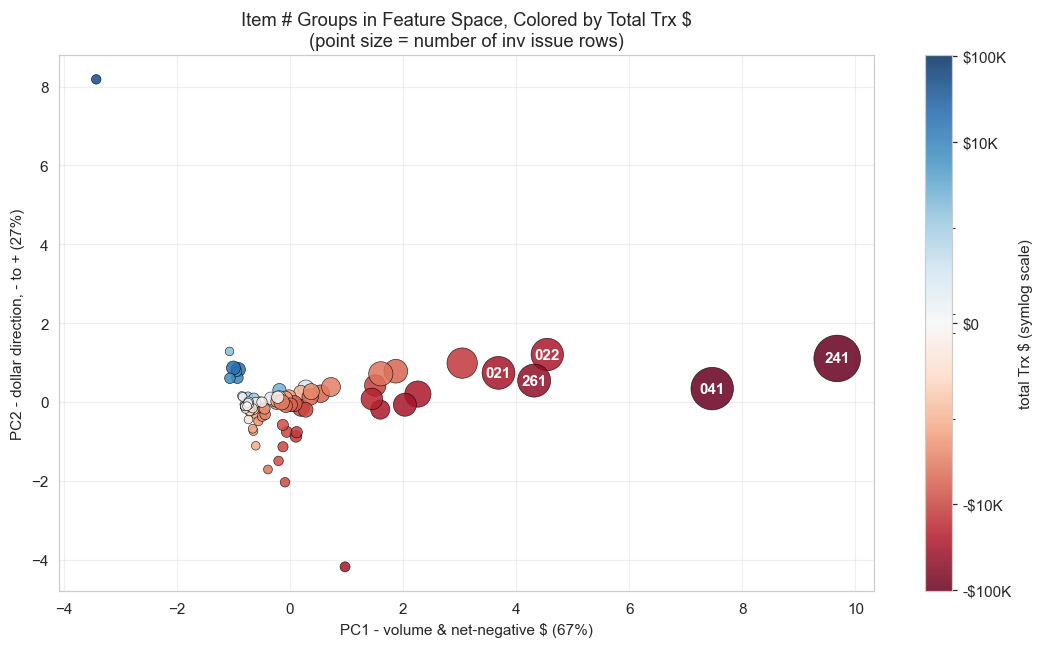

In [14]:
cap = float(features['total_amt'].abs().max())
norm = SymLogNorm(linthresh=1_000, vmin=-cap, vmax=cap, base=10)

fig, ax = plt.subplots(figsize=(10, 6))
point_sizes = features['rows'] / features['rows'].max() * 900 + 30
sc = ax.scatter(features['PC1'], features['PC2'], c=features['total_amt'], cmap='RdBu', norm=norm, s=point_sizes, alpha=0.85, edgecolor='black', lw=0.4)
for _, r in features.sort_values('rows', ascending=False).head().iterrows():
    ax.annotate(r['Group'], (r['PC1'], r['PC2']), fontweight='bold', ha='center', va='center', color='white')
ticks = [-1e6, -1e5, -1e4, 0, 1e4, 1e5, 1e6]
cbar = fig.colorbar(sc, ax=ax, ticks=ticks, label='total Trx $ (symlog scale)')
cbar.ax.yaxis.set_major_formatter(FuncFormatter(dollars))
ax.set(title='Item # Groups in Feature Space, Colored by Total Trx $\n(point size = number of inv issue rows)', xlabel=f'PC1 - volume & net-negative $ ({pca.explained_variance_ratio_[0]:.0%})', ylabel=f'PC2 - dollar direction, - to + ({pca.explained_variance_ratio_[1]:.0%})')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [15]:
profile = features.groupby('cluster').agg(groups=('Group', 'size'), avg_rows=('rows', 'mean'), avg_total_amt=('total_amt', 'mean'), avg_mean_amt=('mean_amt', 'mean'), avg_items=('items', 'mean')).round(1)
examples = features.sort_values('rows', ascending=False).groupby('cluster')['Group'].apply(lambda s: ', '.join(s.head(5)))
profile['example groups'] = examples
profile

,groups,avg_rows,avg_total_amt,avg_mean_amt,avg_items,example groups
cluster,,,,,,
0,7,6.10,"-10,866.10","-1,923.70",4.30,"222, 342, 228, 271, 231"
1,11,149.80,"-21,840.20",-162.30,49.80,"261, 021, 022, 050, 301"
2,83,13.10,-562.50,-30.00,7.30,"402, 151, 011, 211, 044"
3,1,5.00,"45,897.60","9,179.50",4.00,341
4,2,449.50,"-99,752.00",-225.30,86.50,"241, 041"


There are 104 item groups, and the chart captures about 94% of what makes them different.
- The four measures move together closely, so rows, items, and total dollars all rise and fall as one.
- Most groups, 83 of them, form one big cluster of ordinary, low-activity items.
- Two smaller mid-tier clusters, of 11 and 7 groups, sit behind it.
- A few outliers, a group of 2 and a lone one, carry most of the volume and dollars.

Same story as everywhere else: a small number of item groups account for most of the activity. Groups 241 and 041 are the outliers worth watching. Groups 261, 021, 022, and 050 are busy but not extreme.

## Summary

When did inventory adjustments spike, and are they growing or fading?
- They are heavily weighted toward the early years.
- 2005 to 2007 peak near 9,000 rows a year, then steadily fall to a few hundred by 2023 to 2026.
- This tracks the overall drop in transaction volume.

Which specific months stand out in count or dollars?
- 7 months were flagged.
- The standout is a large January 2026 batch of cycle-count entries, with February dropping back to normal.
- This reads more like a batch of data entry than a real business swing.

Does the dollar change lean consistently one way?
- Mostly yes. The net is negative in 20 of the 22 years, -3.9M across the whole trail.
- 2011 and 2015 flip positive on a single adjustment each, +2.1M for "fix pricing" and +1.3M for a count adjustment.
- Remove those two entries and every year is negative.
- So it is a shrinking trail, but only once those two outliers are accounted for.

Do groups of items fall into distinct patterns?
- Yes: one large ordinary group plus a small tail of heavier ones.
- The 104 groups split into 83 ordinary, two mid-tier groups of 11 and 7, and a few outliers of 2 and 1.

What should we keep an eye on going forward?
- The discrepancy trail is small, shrinking, and concentrated in a few item groups.
- The most useful monitor is the unusual-month flag focused on groups 241 and 041.
- Single large entries deserve their own alert, since one adjustment moved 2011 by +2.1M.
- Keep in mind that single-month spikes are often data-entry batches that correct themselves.